# 05. 스토리라인 정리

이 노트북은 앞선 EDA 결과를 자기소개서 문장으로 바꾸기 위한 정리용이다.
핵심은 기술 나열이 아니라 **문제 → 가설 → 분석 → 검증 → 보완 → 비즈니스 임팩트** 흐름이다.



In [1]:
from pathlib import Path
import sys, os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# matplotlib 캐시는 이 EDA 폴더 안에만 만들도록 고정한다.
MPL_CACHE_DIR = Path(r'C:/Users/hyunj/Seoul_Strolling_Adventure/Business_Impact_EDA/.matplotlib_cache')
MPL_CACHE_DIR.mkdir(exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPL_CACHE_DIR))

import matplotlib
if 'ipykernel' not in sys.modules:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'Business_Impact_EDA' else Path(r'C:/Users/hyunj/Seoul_Strolling_Adventure')

# 노트북/Colab/로컬 환경에서 한글 폰트가 깨지지 않도록 설정
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
    get_ipython().run_line_magic('config', "InlineBackend.figure_format = 'retina'")
except Exception:
    pass

import os
import shutil
import subprocess
import matplotlib as mpl
from matplotlib import font_manager as fm

# Colab/Linux 계열이면 나눔/Noto CJK 폰트 설치를 시도한다.
# Windows 로컬에서는 apt-get이 없으므로 설치를 건너뛰고 Malgun Gothic을 우선 사용한다.
if shutil.which('apt-get'):
    try:
        subprocess.run(['apt-get', 'update', '-qq'], check=False)
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum', 'fonts-nanum-extra', 'fonts-noto-cjk'],
                       check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    except Exception as e:
        print('폰트 설치 단계 건너뜀:', e)

# 캐시 삭제 & 폰트 매니저 재로딩
try:
    shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)
    Path(mpl.get_cachedir()).mkdir(parents=True, exist_ok=True)
    fm._load_fontmanager(try_read_cache=False)
except Exception as e:
    print('폰트 캐시 초기화 단계 건너뜀:', e)

# 우선순위: Colab/Linux용 나눔바른고딕 > 나눔고딕 > Noto CJK > Windows 맑은 고딕
candidates = ['NanumBarunGothic', 'NanumGothic', 'Noto Sans CJK KR', 'Malgun Gothic', 'AppleGothic']
avail = {name: any(name in font.name for font in fm.fontManager.ttflist) for name in candidates}
chosen = next((name for name in candidates if avail.get(name)), 'DejaVu Sans')

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = [chosen]
plt.rcParams['axes.unicode_minus'] = False
print('Using font:', chosen)

def read_csv(path, **kwargs):
    for enc in ['utf-8-sig', 'utf-8', 'cp949']:
        try:
            return pd.read_csv(path, encoding=enc, **kwargs)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, **kwargs)

def find_csv_by_cols(folder, required_cols):
    for p in sorted(Path(folder).rglob('*.csv')):
        try:
            cols = set(read_csv(p, nrows=0).columns)
            if set(required_cols).issubset(cols):
                return p
        except Exception:
            pass
    raise FileNotFoundError(f'{folder} 안에서 컬럼 {required_cols}를 가진 csv를 찾지 못했습니다.')

def pct(a, b):
    if b == 0 or pd.isna(b):
        return np.nan
    return (a - b) / b * 100

DATA = {
    'ui_places': find_csv_by_cols(PROJECT_ROOT / 'UI', ['title', 'tour_score', 'review_score']),
    'congestion': find_csv_by_cols(PROJECT_ROOT / 'UI' / 'congestion_level', ['시간대', 'final_level']),
    'tourism_index': next(PROJECT_ROOT.rglob('final_data_Tourism.csv')),
    'popularity': PROJECT_ROOT / 'EDA' / 'popularity' / 'popularity_result.csv',
    'reviews': PROJECT_ROOT / 'EDA' / 'popularity' / 'zb_review_data_final.csv',
}

print('PROJECT_ROOT =', PROJECT_ROOT)
print('사용 데이터 존재 여부')
for k, v in DATA.items():
    print(f'{k:15s}: {v.exists()} | {v.relative_to(PROJECT_ROOT)}')






Using font: NanumGothic
PROJECT_ROOT = c:\Users\hyunj\Seoul_Strolling_Adventure
사용 데이터 존재 여부
ui_places      : True | UI\관광지_법정동_매핑결과.csv
congestion     : True | UI\congestion_level\혼잡도 최종등급_전국.csv
tourism_index  : True | EDA\관광지수\final_data_Tourism.csv
popularity     : True | EDA\popularity\popularity_result.csv
reviews        : True | EDA\popularity\zb_review_data_final.csv


In [2]:
tour = read_csv(DATA['tourism_index'])
pop = read_csv(DATA['popularity'])
reviews = read_csv(DATA['reviews'])
cong = read_csv(DATA['congestion'])
places = read_csv(DATA['ui_places'])

category_cols = [c for c in ['힐링','액티비티','문화','음식','쇼핑','숙박'] if c in tour.columns]
tour['total_tour_score'] = tour[category_cols].sum(axis=1)
high_div = tour[tour['체험다양성_엔트로피'] >= tour['체험다양성_엔트로피'].quantile(.75)]['total_tour_score']
low_div = tour[tour['체험다양성_엔트로피'] <= tour['체험다양성_엔트로피'].quantile(.25)]['total_tour_score']
tour_lift = pct(high_div.mean(), low_div.mean())

reviews['연도월_dt'] = pd.to_datetime(reviews['연도월'].astype(str), errors='coerce')
monthly = reviews.dropna(subset=['연도월_dt']).groupby('연도월_dt').agg(review_count=('리뷰내용','size'), positive_score=('긍정점수','mean')).reset_index().sort_values('연도월_dt')
monthly_for_growth = monthly.copy()
partial_month_note = '없음'
if len(monthly_for_growth) >= 4:
    last_count = monthly_for_growth['review_count'].iloc[-1]
    prev_median = monthly_for_growth['review_count'].iloc[-4:-1].median()
    if last_count < prev_median * 0.7:
        partial_month_note = f"{monthly_for_growth['연도월_dt'].iloc[-1].strftime('%Y-%m')} 부분집계 가능성으로 제외"
        monthly_for_growth = monthly_for_growth.iloc[:-1].copy()
recent = monthly_for_growth.tail(6)
review_growth = pct(recent['review_count'].iloc[-1], recent['review_count'].iloc[0]) if len(recent) >= 2 else np.nan
positive_growth = pct(recent['positive_score'].iloc[-1], recent['positive_score'].iloc[0]) if len(recent) >= 2 else np.nan

level_order = ['여유', '보통', '붐빔', '매우 붐빔']
cong['final_level'] = pd.Categorical(cong['final_level'], categories=level_order, ordered=True)
cong['risk_score'] = cong['final_level'].cat.codes + 1
hourly = cong.groupby('시간대', observed=False).agg(busy_or_more_rate=('final_level', lambda s: (s.astype(str).isin(['붐빔','매우 붐빔'])).mean()*100)).reset_index()
peak = hourly.loc[hourly['busy_or_more_rate'].idxmax()]
quiet = hourly.loc[hourly['busy_or_more_rate'].idxmin()]

places['tour_score'] = pd.to_numeric(places['tour_score'], errors='coerce')
places['review_score'] = pd.to_numeric(places['review_score'], errors='coerce')
places['tour_rank_pct'] = places['tour_score'].rank(pct=True)
places['review_rank_pct'] = places['review_score'].rank(pct=True)
places['strategy_gap'] = places['tour_rank_pct'] - places['review_rank_pct']
strategy_split_rate = (places['strategy_gap'].abs() >= .35).mean() * 100

impact = pd.DataFrame([
    {'지표': '다양성 상위 지역의 관광 총점 차이', '값': f'{tour_lift:.1f}%'},
    {'지표': f'최근 완전월 {len(recent)}개월 리뷰 수 변화율', '값': f'{review_growth:.1f}%'},
    {'지표': f'최근 완전월 {len(recent)}개월 긍정점수 변화율', '값': f'{positive_growth:.1f}%'},
    {'지표': '최고 혼잡 시간대', '값': f"{peak['시간대']} / 붐빔 이상 {peak['busy_or_more_rate']:.1f}%"},
    {'지표': '최저 혼잡 시간대', '값': f"{quiet['시간대']} / 붐빔 이상 {quiet['busy_or_more_rate']:.1f}%"},
    {'지표': '관광지수와 인기도 분리 필요 후보 비율', '값': f'{strategy_split_rate:.1f}%'},
])
impact



,지표,값
0,다양성 상위 지역의 관광 총점 차이,-33.0%
1,최근 완전월 6개월 리뷰 수 변화율,18.3%
2,최근 완전월 6개월 긍정점수 변화율,3.4%
3,최고 혼잡 시간대,17시 / 붐빔 이상 99.5%
4,최저 혼잡 시간대,09시 / 붐빔 이상 0.1%
5,관광지수와 인기도 분리 필요 후보 비율,27.1%


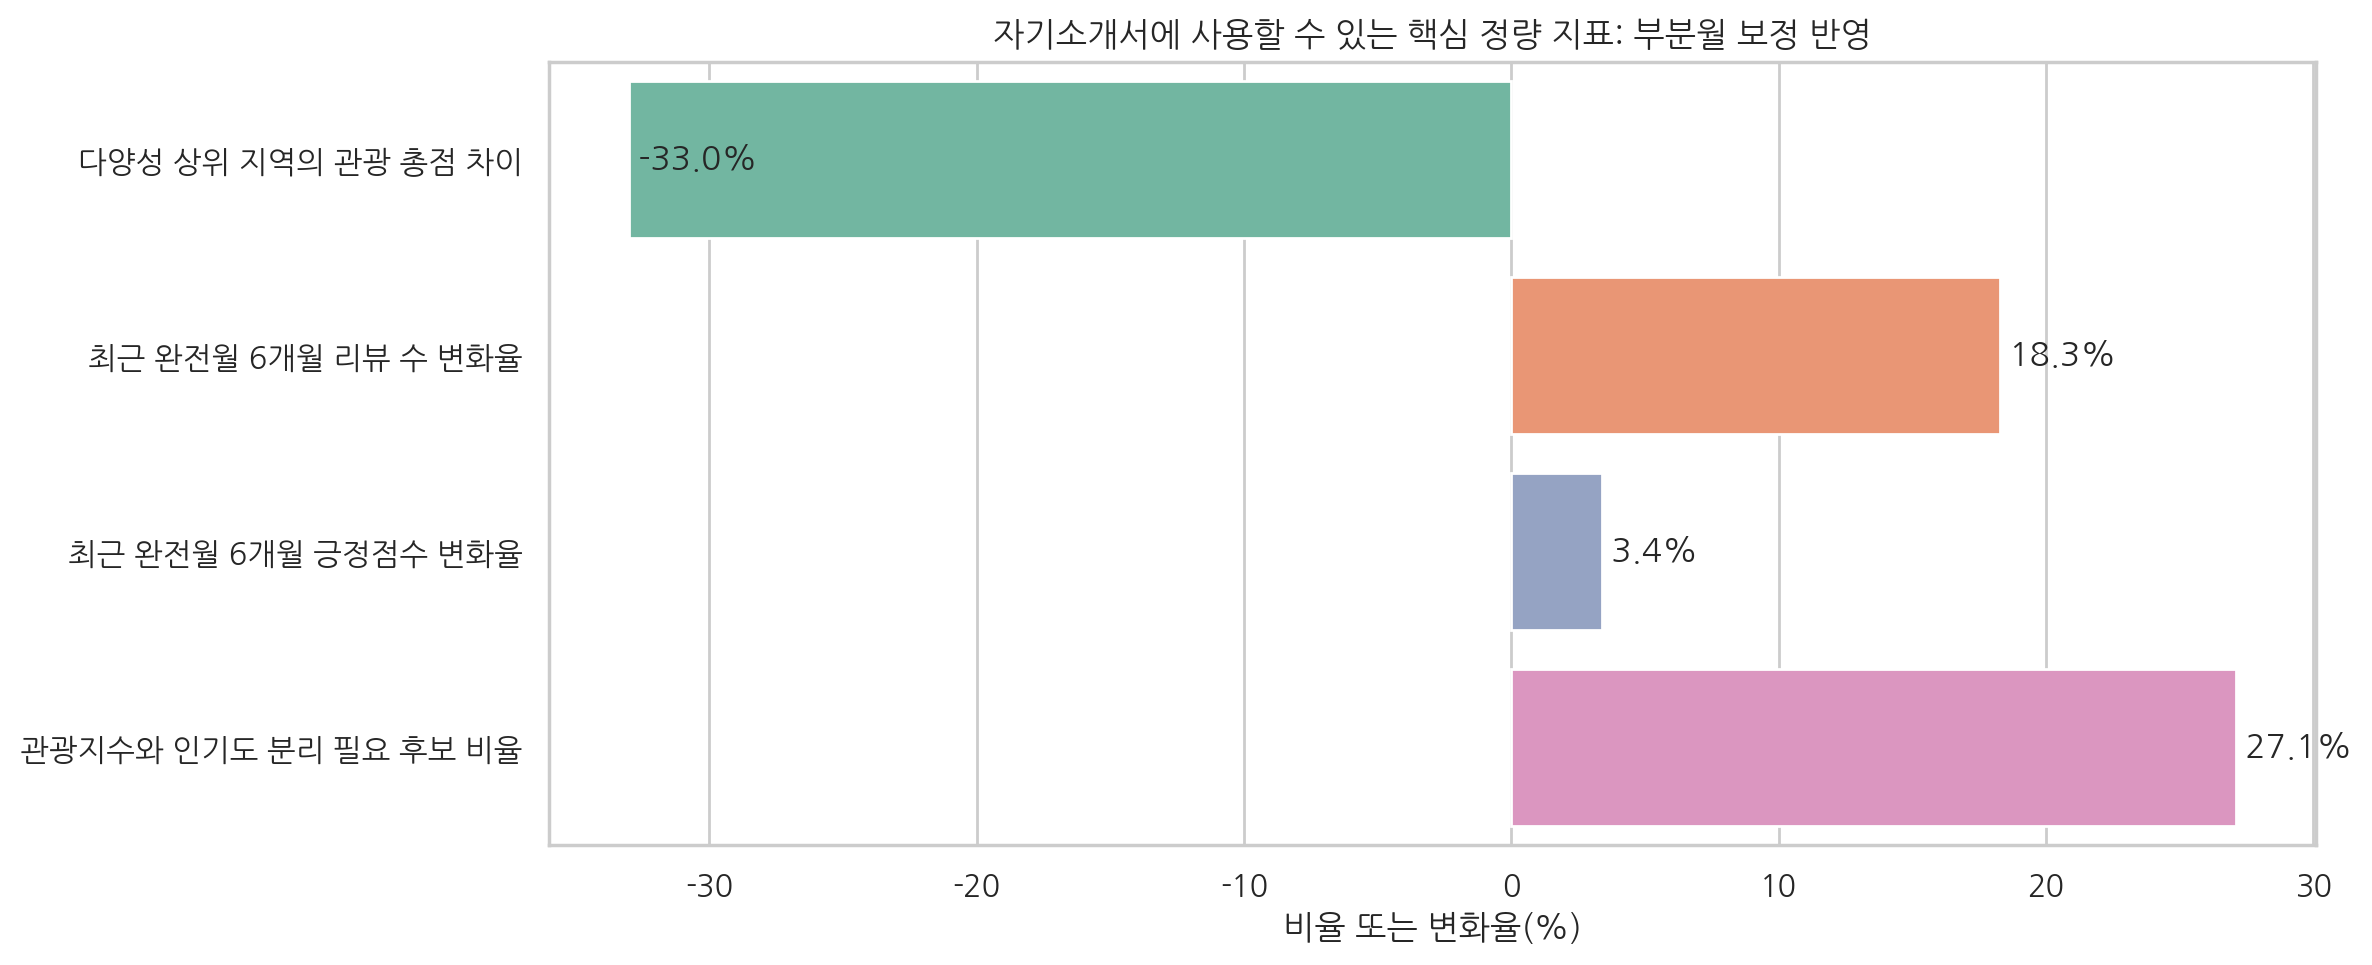

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_df = impact.iloc[[0,1,2,5]].copy()
plot_df['numeric'] = plot_df['값'].str.replace('%','', regex=False).astype(float)
sns.barplot(data=plot_df, y='지표', x='numeric', ax=ax, palette='Set2')
ax.set_title('자기소개서에 사용할 수 있는 핵심 정량 지표: 부분월 보정 반영')
ax.set_xlabel('비율 또는 변화율(%)')
ax.set_ylabel('')
for i, v in enumerate(plot_df['numeric']):
    ax.text(v, i, f' {v:.1f}%', va='center')
plt.tight_layout()
plt.show()



## 스토리라인 초안 구조

### 1. 문제 정의

여행 추천 서비스에서 사용자는 관광지가 많아도 어떤 기준으로 선택해야 할지 어렵고, 인기 장소라도 혼잡하면 만족도가 낮아질 수 있다고 보았습니다.

### 2. 내가 세운 가설

관광지 추천은 단순 평점 순위가 아니라 `관광 자원 다양성`, `리뷰 기반 검증`, `시간대별 혼잡도`를 함께 고려해야 실제 방문 만족도를 높일 수 있다고 가정했습니다.

### 3. 분석과 검증

TourAPI 관광지 데이터를 행정동 단위로 묶어 카테고리 다양성을 계산했고, 리뷰 데이터는 리뷰 수, 평점, 긍정 점수를 함께 반영했습니다. 또한 교통카드 이용량을 시간대별 혼잡도 등급으로 변환해 추천 일정의 실행 가능성을 검증했습니다.

### 4. 보완한 점

처음에는 인기 지표 하나로 추천하려 했지만, 분석 결과 관광지수와 인기도가 서로 다른 목적을 설명한다는 점을 확인했습니다. 그래서 UI에서 사용자가 `관광지수 중심`과 `인기도 중심`을 선택하도록 구조를 분리했습니다.

### 5. 깨달은 점

이 프로젝트를 통해 좋은 모델을 만드는 것만큼, 비즈니스 문제를 명확히 정의하고 데이터를 통해 가설을 검증한 뒤 사용자가 이해할 수 있는 방식으로 보완하는 과정이 더 중요하다는 것을 배웠습니다.



## 스토리라인 한 문장

“저는 관광 추천 프로젝트에서 사용자의 선택 피로와 방문 경험 저하 문제를 데이터로 해결하고자 했습니다. 관광지수, 인기도, 혼잡도를 각각 분리해 계산하고, 통계 검정과 교차검증으로 지표 구조를 검증한 뒤 UI에서 선택 기준을 분리했습니다. 이를 통해 단순 구현이 아니라 비즈니스 문제를 수치로 정의하고 개선안을 도출하는 경험을 했습니다.”

